In [1]:
%load_ext autoreload
%autoreload 2

In [20]:
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from mad.configs.ballistic_objects import titan1_stages, titan2_stages, minuteman_stages
from mad.configs.warheads import B53_warhead
from mad.configs.planets import EARTH_SETTINGS
from mad.objs import Planet, PlanetConfig
from mad.objs import BallisticMissileConfig, MissileStage, MissileStageConfig, BallisticMissile, RVConfig
from mad.guidances import TabulatedBallistic, NoGuidance
from mad.simulation import Simulation
from mad.logger import SourceLogger

logger = SourceLogger()

In [21]:
EARTH_SETTINGS["position"] = [0.0, 0.0]

launchsite_target_distance_km = 1000
earth = Planet(PlanetConfig(**EARTH_SETTINGS))
launchpad = earth.create_2D_point(name="Launchpad", altitude=10)
target = earth.create_2D_point_at_distance(launchpad, distance_km=launchsite_target_distance_km, name="Target")

earth

Planet Earth at [0. 0. 0.]
Mass 5.97e+24 kg, Radius 6371.0 km.
Gravity at surface: -9.82 m/s^2
Orbital velocity: 7909.55 m/s
Escape velocity: 11185.79 m/s

In [22]:
missile_stages = [MissileStage(MissileStageConfig(**stage_cfg)) for stage_cfg in titan1_stages]

missile_guidance = TabulatedBallistic(planet=earth, target=target, ballistic_table_path="B53_warhead_fine")
warhead_guidance = NoGuidance(planet=earth, target=target)

payload_cfg = RVConfig(**B53_warhead)
payload_cfg.guidance = warhead_guidance

missile_cfg = BallisticMissileConfig(stages=missile_stages, 
                                     guidance=missile_guidance, 
                                     payload=payload_cfg, 
                                     n_RVs = 5, 
                                     RV_separation_interval=5.0)
titan = BallisticMissile(position=launchpad.position.copy(), cfg=missile_cfg, name="Titan I")

titan

BallisticMissile Titan I, active.
Stages: Stage1, Stage2.
Available deltaV: 11818.37 m/s.
Burned Fraction: 0.00.

In [23]:
dt = 0.5
max_time = 20_000.

sim = Simulation(max_time=max_time, dt=dt)
sim.run(
    planet=earth,
    moving_objs=[titan],
)

df = sim.results


21:02:23 | INFO     | Simulation   | Starting simulation.
21:02:23 | INFO     | Missile      | Stage1 ran out of propellant at 109.00.
21:02:23 | INFO     | Missile      | Titan I - Stage1 separated at 109.00.
21:02:23 | INFO     | Simulation   | New objects spawned this step: ['Stage1']
21:02:23 | INFO     | Missile      | Titan I released payload B53Warhead_1 at 152.50.
21:02:23 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_1']
21:02:23 | INFO     | Missile      | Titan I released payload B53Warhead_2 at 158.00.
21:02:23 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_2']
21:02:23 | INFO     | Missile      | Titan I released payload B53Warhead_3 at 163.50.
21:02:23 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_3']
21:02:23 | INFO     | Missile      | Titan I released payload B53Warhead_4 at 169.00.
21:02:23 | INFO     | Simulation   | New objects spawned this step: ['B53Warhead_4']
21:02:23 | INFO     | Missi

In [24]:
df.sample(5)

,time,name,_id,position,velocity,posx,posz,speed,altitude,gamma
4434,280.0,B53Warhead_5,ReentryVehicle_B53Warhead_30,"[4322413.0962186195, -4964048.888046211, 0.0]","[1857.4632291259804, 1342.9485317679864, 0.0]",4.322413e+06,-4.964049e+06,2292.090837,6.582176e+06,NaN
675,272.0,Stage1,Projectile_Stage1_25,"[4218786.9717871025, -4975317.475257011, 0.0]","[1280.2848802594494, 1292.6427698673292, 0.0]",4.218787e+06,-4.975317e+06,1819.355574,6.523185e+06,NaN
3303,438.0,B53Warhead_3,ReentryVehicle_B53Warhead_28,"[4538622.338429193, -4665892.292241577, 0.0]","[866.9536719386722, 2420.72087893339, 0.0]",4.538622e+06,-4.665892e+06,2571.283384,6.509197e+06,NaN
330,165.0,Titan I,BallisticMissile_Titan I_24,"[4069270.176859797, -5071841.695386816, 0.0]","[2542.191619179852, 524.2548881529522, 0.0]",4.069270e+06,-5.071842e+06,2595.685154,6.502502e+06,0.47192
2028,170.5,B53Warhead_2,ReentryVehicle_B53Warhead_27,"[4083167.8899570033, -5068874.232824166, 0.0]","[2510.1159901971946, 562.5438287090204, 0.0]",4.083168e+06,-5.068874e+06,2572.379802,6.508897e+06,NaN


In [25]:
df["altitude_km"] = df["position"].apply(lambda pos: (np.linalg.norm(pos) - earth.radius) / 1e3)
df["energy_kJ"] = df["speed"].apply(lambda speed: 0.5 * speed**2 / 1e3)
df["gamma_deg"] = df["gamma"].apply(lambda g: np.degrees(g) if g is not None else None)
df = df.sort_values(by=["name", "time"])

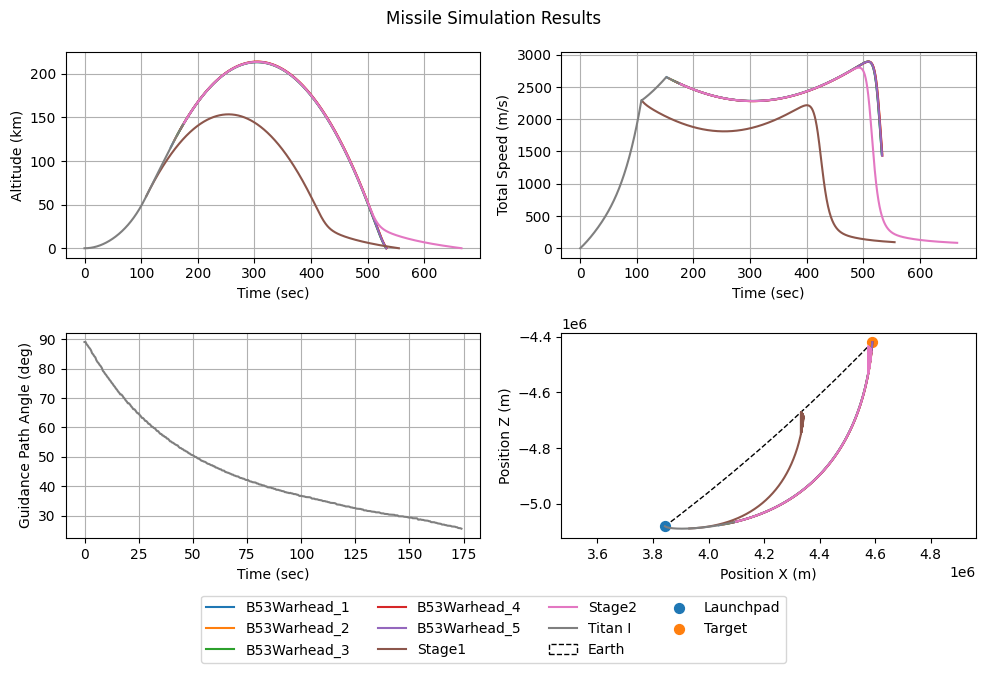

In [26]:
fig, ax = plt.subplots(ncols=2, nrows=2, figsize=(10, 6))
ax = ax.ravel()

sns.lineplot(data=df, x="time", y="altitude_km", hue="name", ax=ax[0])
sns.lineplot(data=df, x="time", y="speed", hue="name", ax=ax[1])
sns.lineplot(data=df, x="time", y="gamma_deg", hue="name", ax=ax[2])
sns.lineplot(data=df, x="posx", y="posz", hue="name", ax=ax[3])

ax[0].set_xlabel("Time (sec)")
ax[0].set_ylabel("Altitude (km)")

ax[1].set_xlabel("Time (sec)")
ax[1].set_ylabel("Total Speed (m/s)")

ax[2].set_xlabel("Time (sec)")
ax[2].set_ylabel("Guidance Path Angle (deg)")

earth.plot_2D_with_points(points = [launchpad, target], ax=ax[3], display="arc")
ax[3].set_xlabel("Position X (m)")
ax[3].set_ylabel("Position Z (m)")
ax[3].set_aspect("equal", adjustable="datalim")

for a in ax:
    a.grid()
    a.legend()
    handles, labels = a.get_legend_handles_labels()
    a.legend().remove()

fig.suptitle("Missile Simulation Results")
fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.12))
fig.tight_layout(pad=1.2)